`python -m venv .venv`

`call venv\Scripts\activate`

`python -m pip install --upgrade pip`

`pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121`

`pip install keras numpy`

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import torch
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available() == False:
    print(f"GPU is not found!!!!!")


PyTorch version: 2.6.0+cu124
CUDA available: True


In [12]:
from keras import backend as K
print(K.backend())

torch


In [ ]:
from keras.datasets import cifar10

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training shape: {x_train.shape}") # Should be (50000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training shape: (50000, 32, 32, 3)


Fully Connected Network model (FCN)

In [36]:
model_fcn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)), # Explicit Input layer
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_fcn.compile(optimizer='adamw',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_fcn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Convolutional Network (CNN)

In [40]:
model_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)), 
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adamw',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## FCN Part

In [ ]:
history_fcn = model_fcn.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.3128 - loss: 1.9057 - val_accuracy: 0.3607 - val_loss: 1.7551
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.3887 - loss: 1.7029 - val_accuracy: 0.3950 - val_loss: 1.6920
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4185 - loss: 1.6253 - val_accuracy: 0.4263 - val_loss: 1.6204
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4432 - loss: 1.5572 - val_accuracy: 0.4424 - val_loss: 1.5739
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4581 - loss: 1.5159 - val_accuracy: 0.4479 - val_loss: 1.5540
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4723 - loss: 1.4753 - val_accuracy: 0.4718 - val_loss: 1.5074
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4834 - loss: 1.4420 - val_accuracy: 0.4746 - val_loss: 1.4908
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4946 - loss: 1.4173 - 

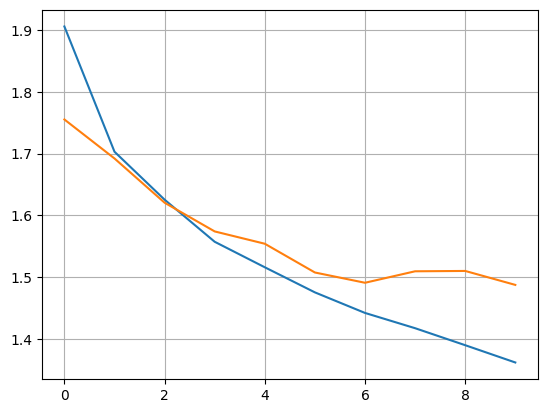

In [ ]:
plt.plot(history_fcn.history["loss"])
plt.plot(history_fcn.history["val_loss"])
plt.grid()
plt.show()

In [44]:
test_scores = model_fcn.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 4s - 13ms/step - accuracy: 0.4829 - loss: 1.4543
Test loss: 1.4542535543441772
Test accuracy: 0.4828999936580658


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


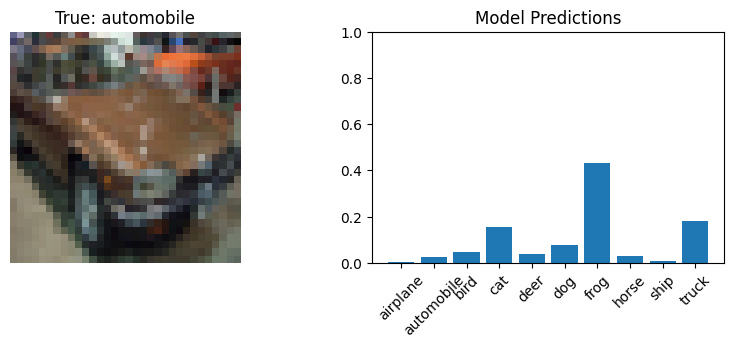

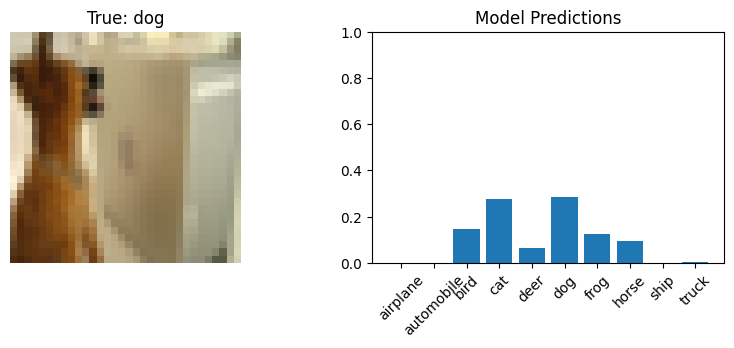

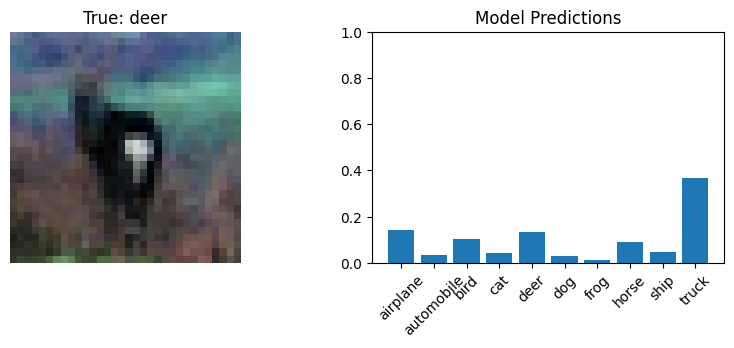

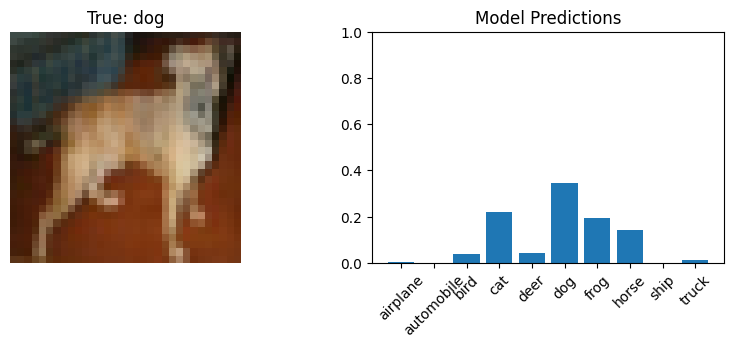

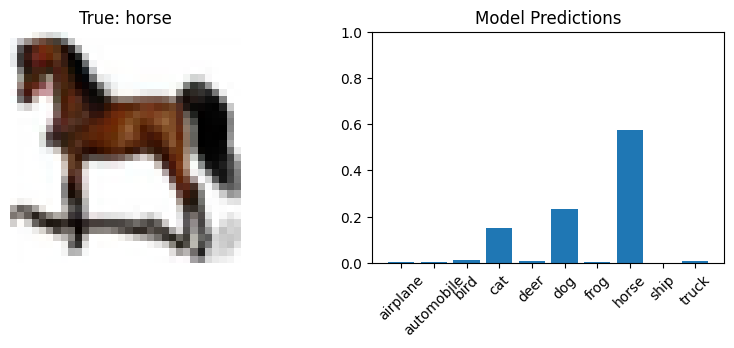

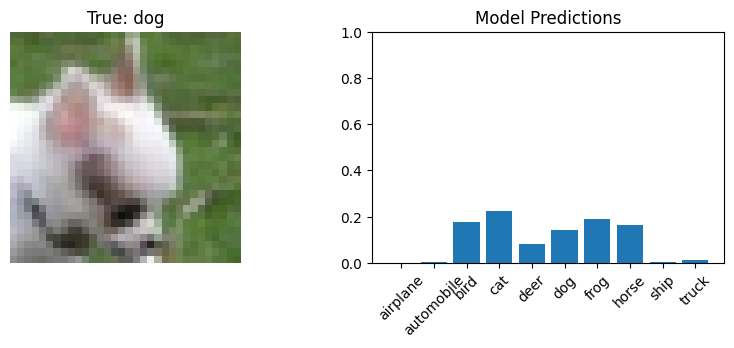

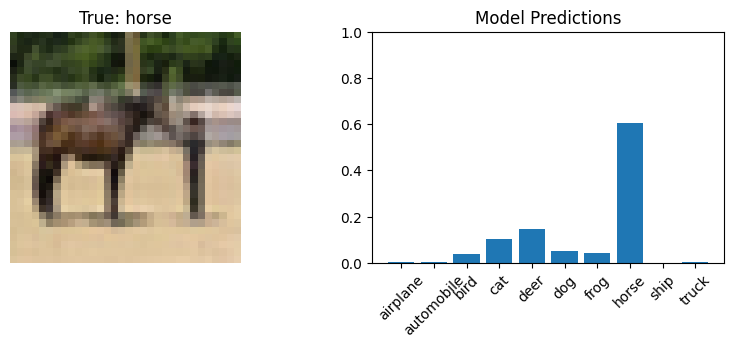

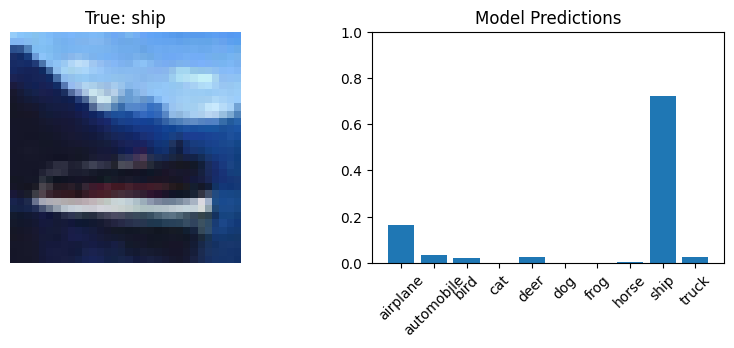

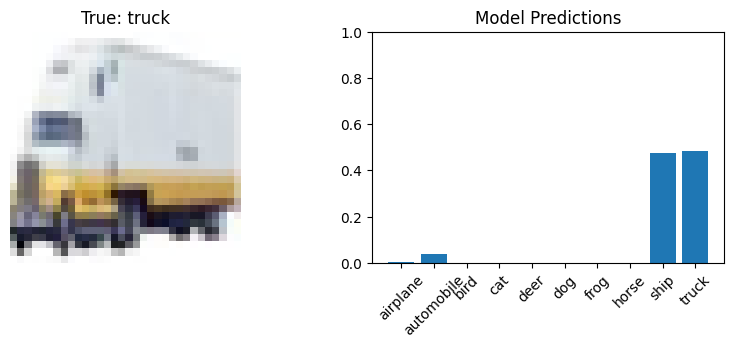

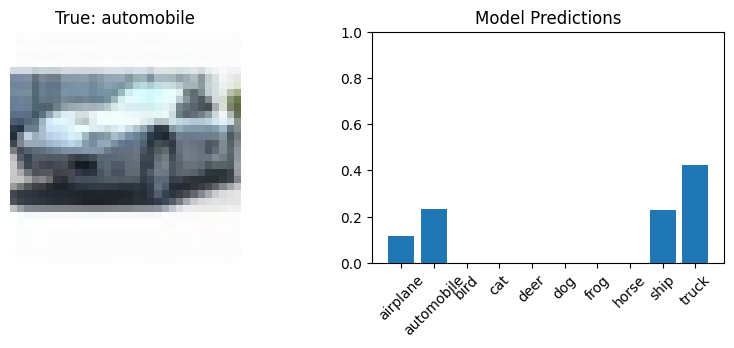

In [ ]:
y_pred = model_fcn.predict(x_test) 

start = 2000
for k in range(10):
    idx = start + k
    plt.figure(figsize=(10, 3))
    
    # Left side: The Image
    plt.subplot(1, 2, 1)
    plt.imshow(x_test[idx]) 
    plt.title(f"True: {class_names[y_test[idx][0]]}")
    plt.axis('off')
    
    # Right side: The Probabilities
    plt.subplot(1, 2, 2)
    plt.bar(range(10), y_pred[idx])
    plt.xticks(range(10), class_names, rotation=45)
    plt.ylim([0, 1])
    plt.title("Model Predictions")
    plt.show()

## CNN Part

In [47]:
history_cnn = model_cnn.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4291 - loss: 1.5790 - val_accuracy: 0.5343 - val_loss: 1.3172
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.5646 - loss: 1.2380 - val_accuracy: 0.5711 - val_loss: 1.2103
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6088 - loss: 1.1096 - val_accuracy: 0.6150 - val_loss: 1.1126
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6422 - loss: 1.0231 - val_accuracy: 0.6256 - val_loss: 1.0862
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6654 - loss: 0.9580 - val_accuracy: 0.6534 - val_loss: 0.9988
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.6871 - loss: 0.9021 - val_accuracy: 0.6374 - val_loss: 1.0495
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6995 - loss: 0.8647 - val_accuracy: 0.6685 - val_loss: 0.9673
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.7135 - loss: 0.8215 - 

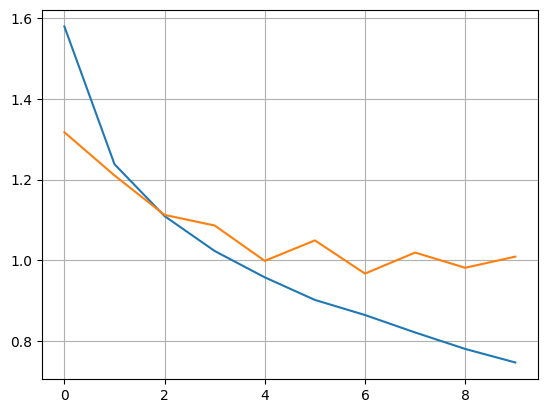

In [49]:
plt.plot(history_cnn.history["loss"])
plt.plot(history_cnn.history["val_loss"])
plt.grid()
plt.show()

In [50]:
test_scores = model_cnn.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 6s - 19ms/step - accuracy: 0.6616 - loss: 1.0024
Test loss: 1.0023998022079468
Test accuracy: 0.6615999937057495


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


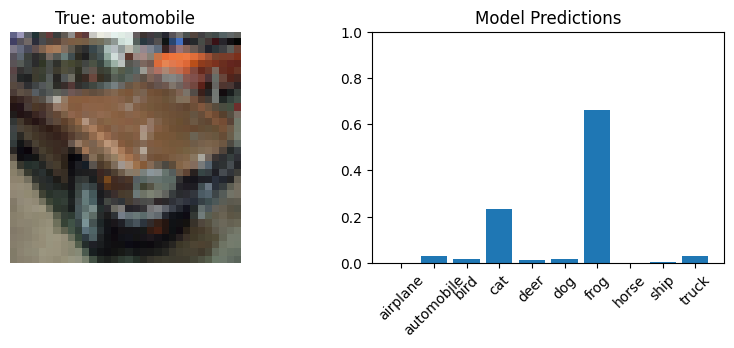

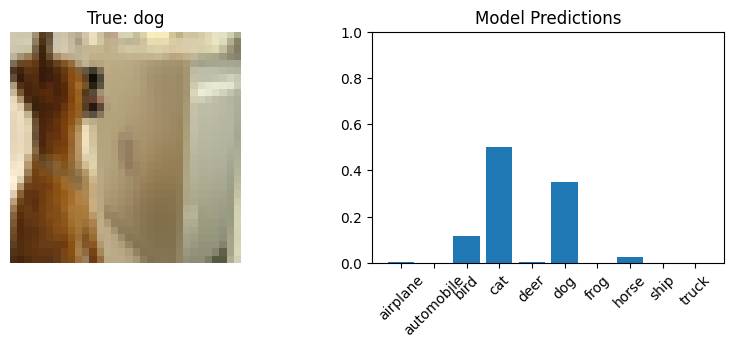

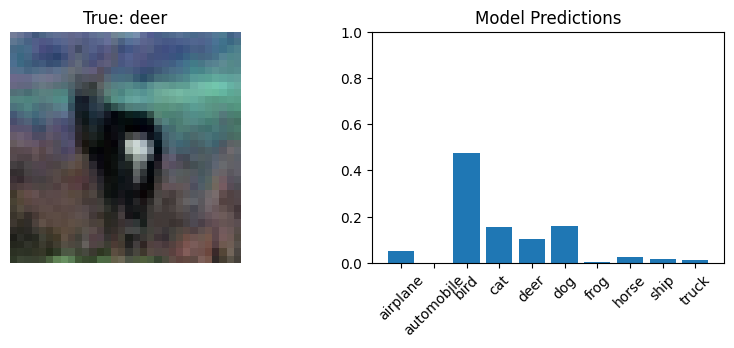

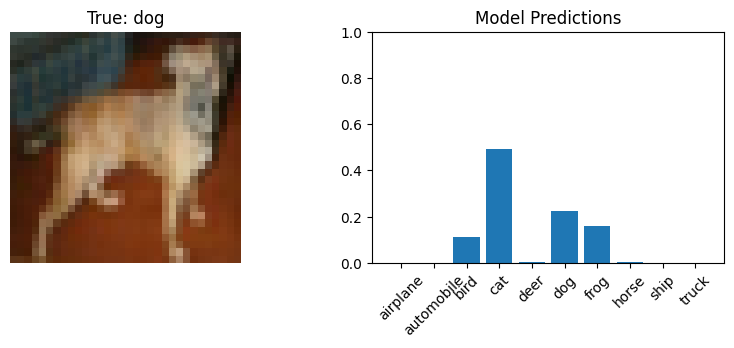

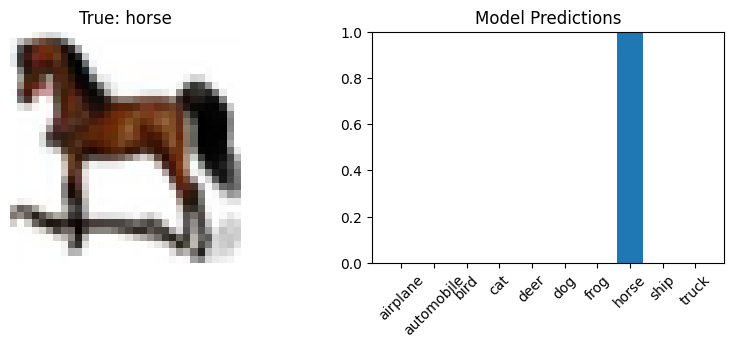

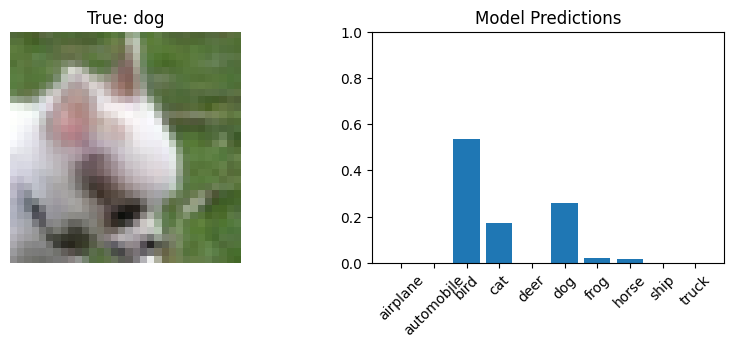

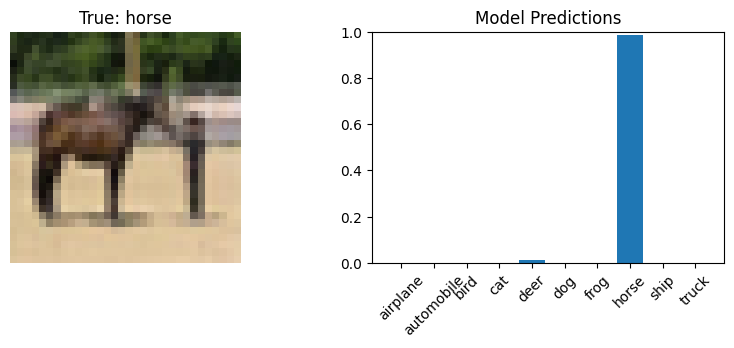

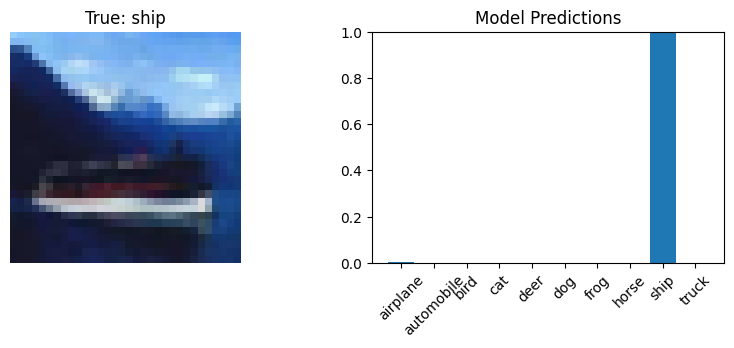

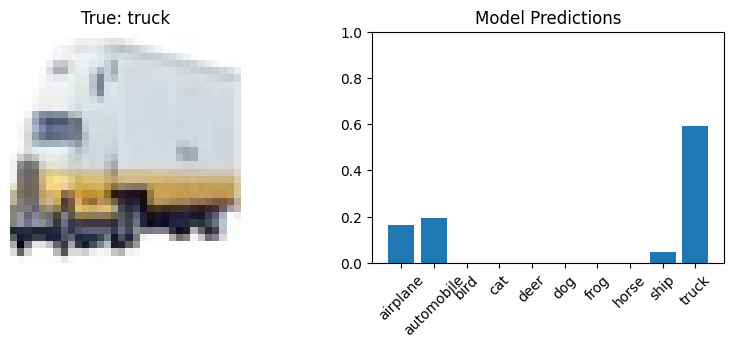

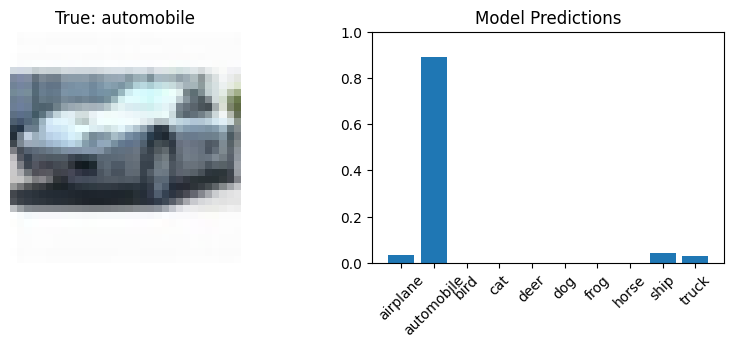

In [51]:
y_pred = model_cnn.predict(x_test) 

start = 2000
for k in range(10):
    idx = start + k
    plt.figure(figsize=(10, 3))
    
    # Left side: The Image
    plt.subplot(1, 2, 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx][0]]}")
    plt.axis('off')
    
    # Right side: The Probabilities
    plt.subplot(1, 2, 2)
    plt.bar(range(10), y_pred[idx])
    plt.xticks(range(10), class_names, rotation=45)
    plt.ylim([0, 1]) 
    plt.title("Model Predictions")
    plt.show()